# Walk-Forward Validation Results

12 quarterly expanding windows (Q1 2023 -- Q1 2026). All models retrained each window (baselines: OLS refit, LightGBM/LSTM: fixed HP, fresh weights).

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.3})

WF_DIR = "../data/processed/evaluation/walk_forward"
wm = pl.read_parquet(f"{WF_DIR}/per_window_metrics.parquet")
sm = pl.read_parquet(f"{WF_DIR}/summary_metrics.parquet")
dm = pl.read_parquet(f"{WF_DIR}/dm_tests_wf.parquet")
ap = pl.read_parquet(f"{WF_DIR}/all_predictions.parquet")

# Consistent model order (by mean QLIKE)
MODEL_ORDER = sm.sort("mean_QLIKE")["model"].to_list()
COLORS = dict(zip(MODEL_ORDER, plt.cm.tab10.colors[:len(MODEL_ORDER)]))

print(f"Windows: {wm['window_id'].n_unique()}, Models: {wm['model'].n_unique()}")
print(f"Per-window rows: {wm.shape[0]}, Predictions: {ap.shape[0]:,}")

Windows: 12, Models: 8
Per-window rows: 96, Predictions: 1,094,906


## 1. Summary Table

In [2]:
summary = sm.sort("mean_QLIKE").select([
    "model",
    pl.col("mean_QLIKE").round(4).alias("QLIKE"),
    pl.col("std_QLIKE").round(4).alias("std"),
    (pl.col("mean_R2_OOS") * 100).round(1).alias("R2_OOS_%"),
    "n_windows",
])

# Add vs LogHAR column
loghar_qlike = float(sm.filter(pl.col("model") == "LogHAR")["mean_QLIKE"][0])
summary = summary.with_columns(
    ((pl.col("QLIKE") - loghar_qlike) / loghar_qlike * 100).round(1).alias("vs_LogHAR_%")
)
print(summary)

shape: (8, 6)
┌──────────┬────────┬────────┬──────────┬───────────┬─────────────┐
│ model    ┆ QLIKE  ┆ std    ┆ R2_OOS_% ┆ n_windows ┆ vs_LogHAR_% │
│ ---      ┆ ---    ┆ ---    ┆ ---      ┆ ---       ┆ ---         │
│ str      ┆ f64    ┆ f64    ┆ f64      ┆ u32       ┆ f64         │
╞══════════╪════════╪════════╪══════════╪═══════════╪═════════════╡
│ LightGBM ┆ 0.0231 ┆ 0.0028 ┆ 93.5     ┆ 12        ┆ -17.4       │
│ LogHAR   ┆ 0.028  ┆ 0.0051 ┆ 93.5     ┆ 12        ┆ 0.1         │
│ SHAR     ┆ 0.0281 ┆ 0.0038 ┆ 93.7     ┆ 12        ┆ 0.5         │
│ HARQ     ┆ 0.0283 ┆ 0.0045 ┆ 93.6     ┆ 12        ┆ 1.2         │
│ LevHAR   ┆ 0.0287 ┆ 0.0044 ┆ 93.6     ┆ 12        ┆ 2.6         │
│ HAR      ┆ 0.0287 ┆ 0.0045 ┆ 93.6     ┆ 12        ┆ 2.6         │
│ LSTM     ┆ 0.0428 ┆ 0.0133 ┆ 88.9     ┆ 12        ┆ 53.1        │
│ AR5      ┆ 0.419  ┆ 0.0626 ┆ 39.1     ┆ 12        ┆ 1398.5      │
└──────────┴────────┴────────┴──────────┴───────────┴─────────────┘


## 2. QLIKE by Window (Line Chart)

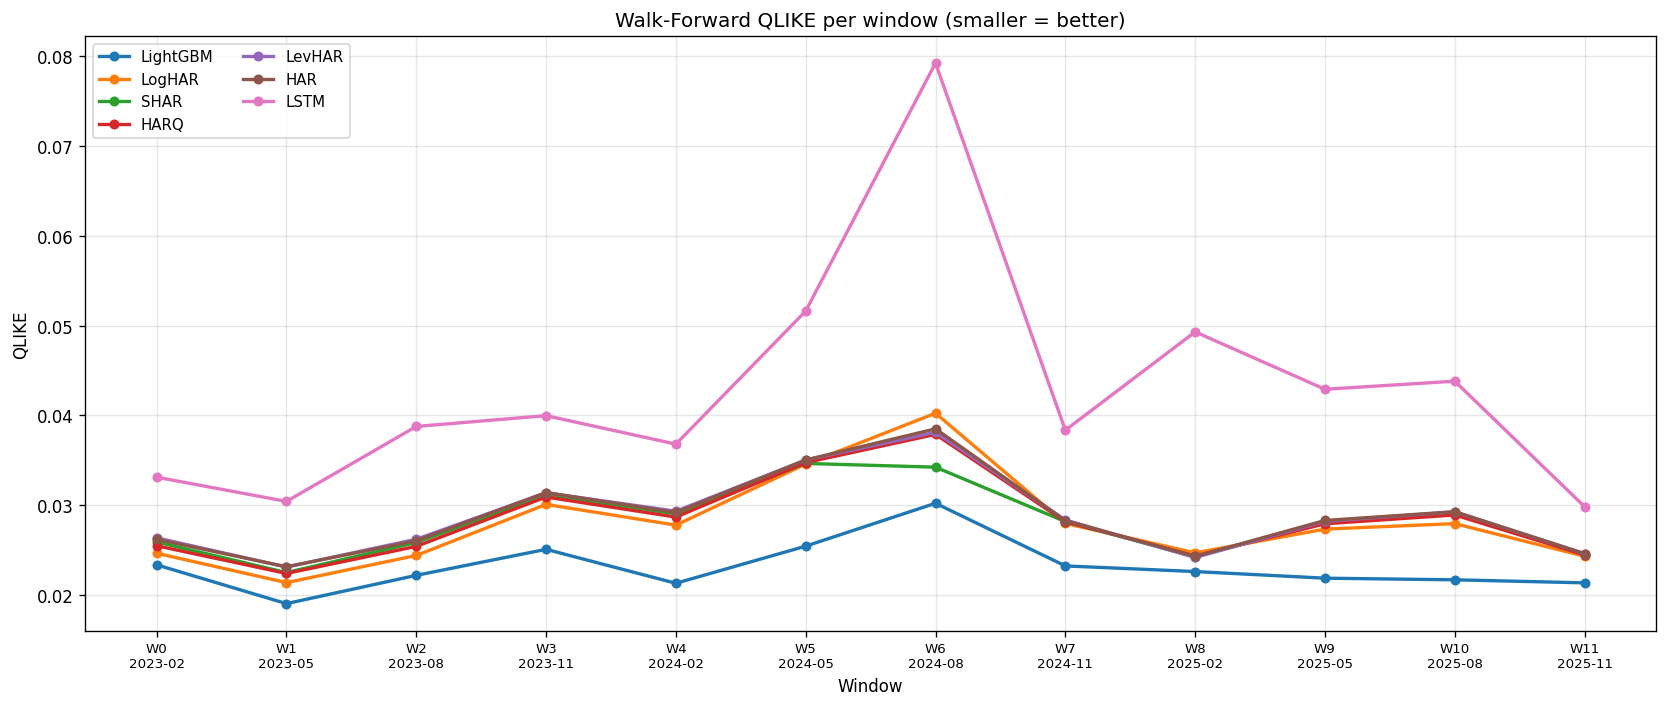

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

# Exclude AR5 (too high, compresses scale)
plot_models = [m for m in MODEL_ORDER if m != "AR5"]

for model in plot_models:
    sub = wm.filter(pl.col("model") == model).sort("window_id")
    ax.plot(sub["window_id"].to_list(), sub["QLIKE"].to_list(),
            marker="o", label=model, color=COLORS[model], linewidth=2, markersize=5)

ax.set_xlabel("Window")
ax.set_ylabel("QLIKE")
ax.set_title("Walk-Forward QLIKE per window (smaller = better)")
ax.set_xticks(range(12))

# Add test period labels
labels = wm.filter(pl.col("model") == "HAR").sort("window_id")
ax.set_xticklabels([f"W{i}\n{s[:7]}" for i, s in zip(
    labels["window_id"].to_list(), labels["test_start"].to_list()
)], fontsize=8)

ax.legend(loc="upper left", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## 3. QLIKE Heatmap (Model x Window)

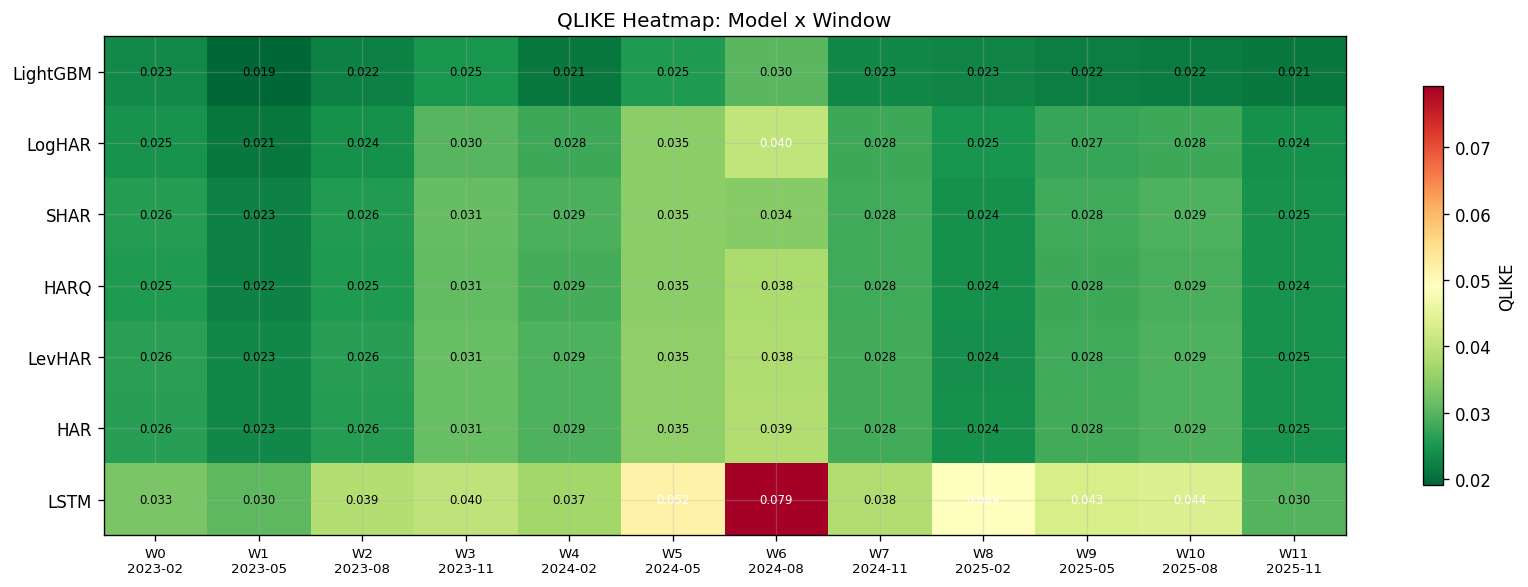

In [4]:
# Pivot to model x window matrix (exclude AR5)
plot_models = [m for m in MODEL_ORDER if m != "AR5"]
pivot = wm.filter(pl.col("model").is_in(plot_models)).pivot(
    on="window_id", index="model", values="QLIKE"
)

# Reorder rows by mean QLIKE
pivot = pivot.with_columns(
    pl.concat_list([c for c in pivot.columns if c != "model"]).list.mean().alias("_mean")
).sort("_mean").drop("_mean")

models = pivot["model"].to_list()
data = pivot.drop("model").to_numpy()

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(data, aspect="auto", cmap="RdYlGn_r")
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)
ax.set_xticks(range(12))

labels_df = wm.filter(pl.col("model") == "HAR").sort("window_id")
ax.set_xticklabels([f"W{i}\n{s[:7]}" for i, s in zip(
    labels_df["window_id"].to_list(), labels_df["test_start"].to_list()
)], fontsize=8)

# Annotate cells
for i in range(len(models)):
    for j in range(12):
        ax.text(j, i, f"{data[i, j]:.3f}", ha="center", va="center", fontsize=7,
                color="white" if data[i, j] > 0.04 else "black")

plt.colorbar(im, ax=ax, label="QLIKE", shrink=0.8)
ax.set_title("QLIKE Heatmap: Model x Window")
plt.tight_layout()
plt.show()

## 4. Window Win Counts

In [5]:
# Which model wins each window?
winners = wm.filter(pl.col("model") != "AR5").group_by("window_id").agg(
    pl.col("model").sort_by("QLIKE").first().alias("best_model"),
    pl.col("QLIKE").min().alias("best_QLIKE"),
).sort("window_id")

print("Best model per window:")
print(winners)

win_counts = winners.group_by("best_model").len().sort("len", descending=True)
print("\nWin counts:")
print(win_counts)

Best model per window:
shape: (12, 3)
┌───────────┬────────────┬────────────┐
│ window_id ┆ best_model ┆ best_QLIKE │
│ ---       ┆ ---        ┆ ---        │
│ i32       ┆ str        ┆ f64        │
╞═══════════╪════════════╪════════════╡
│ 0         ┆ LightGBM   ┆ 0.023374   │
│ 1         ┆ LightGBM   ┆ 0.019055   │
│ 2         ┆ LightGBM   ┆ 0.022204   │
│ 3         ┆ LightGBM   ┆ 0.025098   │
│ 4         ┆ LightGBM   ┆ 0.021321   │
│ …         ┆ …          ┆ …          │
│ 7         ┆ LightGBM   ┆ 0.023253   │
│ 8         ┆ LightGBM   ┆ 0.022626   │
│ 9         ┆ LightGBM   ┆ 0.021888   │
│ 10        ┆ LightGBM   ┆ 0.021706   │
│ 11        ┆ LightGBM   ┆ 0.021369   │
└───────────┴────────────┴────────────┘

Win counts:
shape: (1, 2)
┌────────────┬─────┐
│ best_model ┆ len │
│ ---        ┆ --- │
│ str        ┆ u32 │
╞════════════╪═════╡
│ LightGBM   ┆ 12  │
└────────────┴─────┘


## 5. LightGBM vs LogHAR Improvement by Window

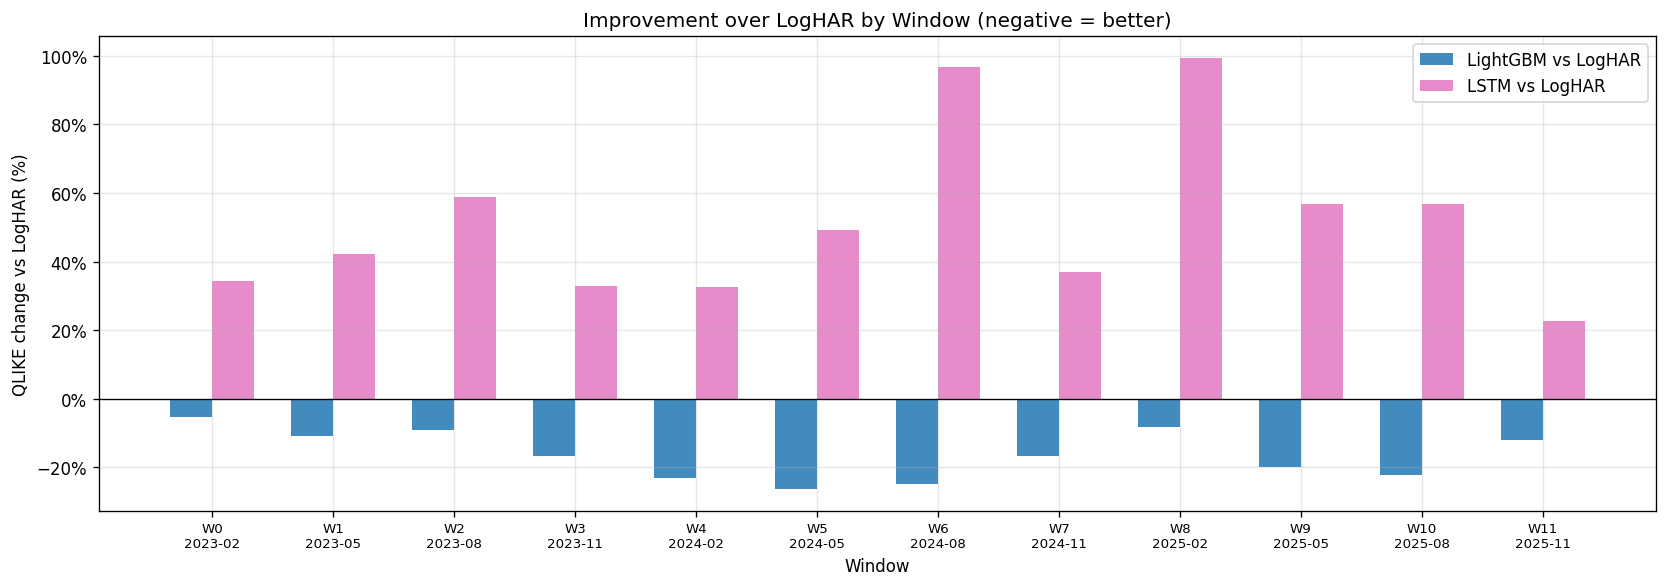


LightGBM wins in 12/12 windows
LSTM wins in 0/12 windows

LightGBM mean improvement: -16.4%
LSTM mean improvement: 51.6%


In [6]:
lgbm = wm.filter(pl.col("model") == "LightGBM").sort("window_id")["QLIKE"].to_numpy()
loghar = wm.filter(pl.col("model") == "LogHAR").sort("window_id")["QLIKE"].to_numpy()
lstm = wm.filter(pl.col("model") == "LSTM").sort("window_id")["QLIKE"].to_numpy()

improvement_lgbm = (lgbm - loghar) / loghar * 100
improvement_lstm = (lstm - loghar) / loghar * 100

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(12)
width = 0.35

bars1 = ax.bar(x - width/2, improvement_lgbm, width, label="LightGBM vs LogHAR",
               color=COLORS["LightGBM"], alpha=0.85)
bars2 = ax.bar(x + width/2, improvement_lstm, width, label="LSTM vs LogHAR",
               color=COLORS["LSTM"], alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Window")
ax.set_ylabel("QLIKE change vs LogHAR (%)")
ax.set_title("Improvement over LogHAR by Window (negative = better)")
ax.set_xticks(x)

labels_df = wm.filter(pl.col("model") == "HAR").sort("window_id")
ax.set_xticklabels([f"W{i}\n{s[:7]}" for i, s in zip(
    labels_df["window_id"].to_list(), labels_df["test_start"].to_list()
)], fontsize=8)

ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print(f"\nLightGBM wins in {(improvement_lgbm < 0).sum()}/12 windows")
print(f"LSTM wins in {(improvement_lstm < 0).sum()}/12 windows")
print(f"\nLightGBM mean improvement: {improvement_lgbm.mean():.1f}%")
print(f"LSTM mean improvement: {improvement_lstm.mean():.1f}%")

## 6. LSTM Performance Analysis

LSTM retrained each window (fixed HP, 5-seed ensemble). Despite fresh weights, it underperforms all HAR baselines.

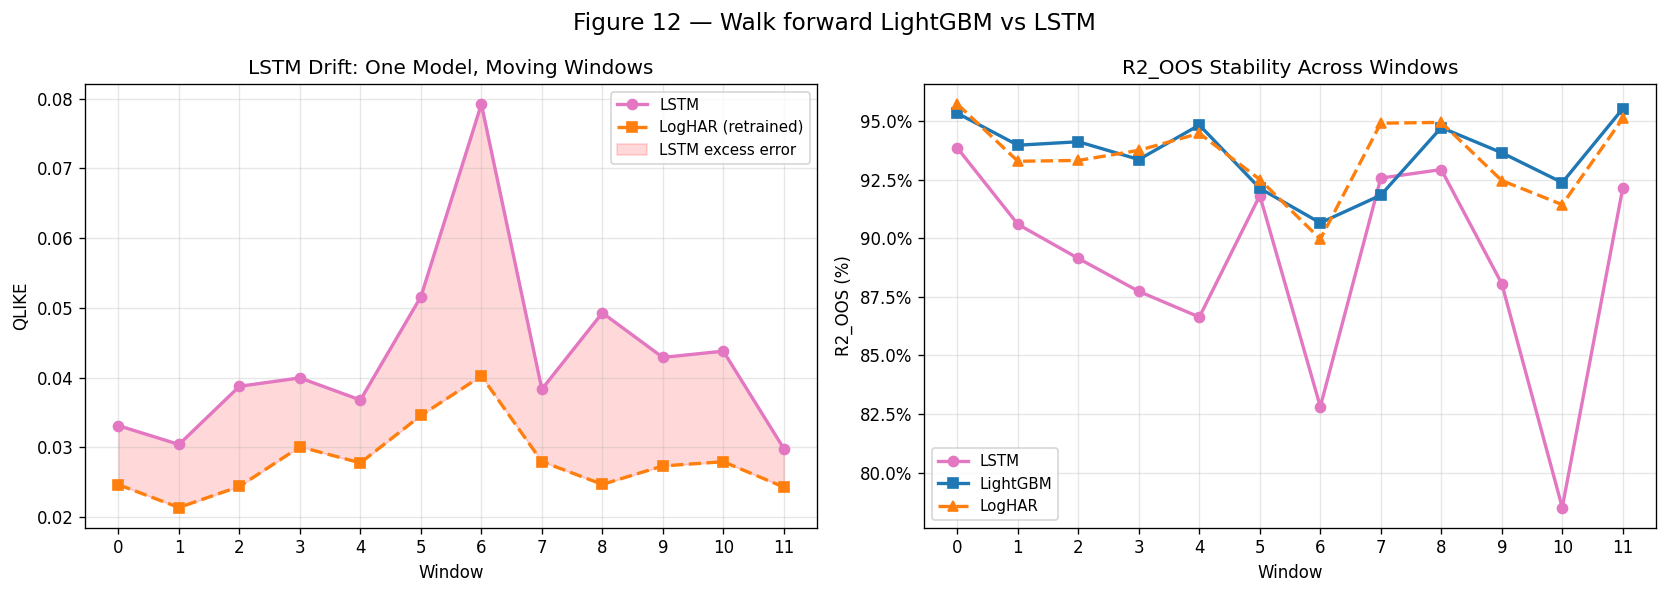

Correlation (window_id vs LSTM QLIKE): 0.182
LSTM QLIKE range: 0.0298 -- 0.0792
LightGBM QLIKE range: 0.0191 -- 0.0302


In [7]:
lstm_wm = wm.filter(pl.col("model") == "LSTM").sort("window_id")
loghar_wm = wm.filter(pl.col("model") == "LogHAR").sort("window_id")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: LSTM QLIKE over time
ax1.plot(range(12), lstm_wm["QLIKE"].to_list(), "o-", color=COLORS["LSTM"],
         linewidth=2, label="LSTM")
ax1.plot(range(12), loghar_wm["QLIKE"].to_list(), "s--", color=COLORS["LogHAR"],
         linewidth=2, label="LogHAR (retrained)")
ax1.fill_between(range(12), lstm_wm["QLIKE"].to_list(), loghar_wm["QLIKE"].to_list(),
                 alpha=0.15, color="red", label="LSTM excess error")
ax1.set_xlabel("Window")
ax1.set_ylabel("QLIKE")
ax1.set_title("LSTM Drift: One Model, Moving Windows")
ax1.legend(fontsize=9)
ax1.set_xticks(range(12))

# Right: LSTM R2_OOS decline
lgbm_wm = wm.filter(pl.col("model") == "LightGBM").sort("window_id")
ax2.plot(range(12), [r * 100 for r in lstm_wm["R2_OOS"].to_list()], "o-",
         color=COLORS["LSTM"], linewidth=2, label="LSTM")
ax2.plot(range(12), [r * 100 for r in lgbm_wm["R2_OOS"].to_list()], "s-",
         color=COLORS["LightGBM"], linewidth=2, label="LightGBM")
ax2.plot(range(12), [r * 100 for r in loghar_wm["R2_OOS"].to_list()], "^--",
         color=COLORS["LogHAR"], linewidth=2, label="LogHAR")
ax2.set_xlabel("Window")
ax2.set_ylabel("R2_OOS (%)")
ax2.set_title("R2_OOS Stability Across Windows")
ax2.legend(fontsize=9)
ax2.set_xticks(range(12))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

fig.suptitle("Figure 12 — Walk forward LightGBM vs LSTM", fontsize=14)
plt.tight_layout()
plt.show()

# Correlation: window_id vs LSTM QLIKE
corr = np.corrcoef(range(12), lstm_wm["QLIKE"].to_numpy())[0, 1]
print(f"Correlation (window_id vs LSTM QLIKE): {corr:.3f}")
print(f"LSTM QLIKE range: {lstm_wm['QLIKE'].min():.4f} -- {lstm_wm['QLIKE'].max():.4f}")
print(f"LightGBM QLIKE range: {lgbm_wm['QLIKE'].min():.4f} -- {lgbm_wm['QLIKE'].max():.4f}")

## 7. Diebold-Mariano Tests

In [8]:
dm_display = dm.sort("dm_stat", descending=True).with_columns([
    pl.col("dm_stat").round(2),
    pl.col("p_value").round(4),
    pl.when(pl.col("p_value") < 0.001).then(pl.lit("***"))
      .when(pl.col("p_value") < 0.01).then(pl.lit("**"))
      .when(pl.col("p_value") < 0.05).then(pl.lit("*"))
      .otherwise(pl.lit("")).alias("sig"),
])
print("DM tests vs LogHAR (positive = better than LogHAR):")
print(dm_display)

DM tests vs LogHAR (positive = better than LogHAR):
shape: (7, 6)
┌──────────┬───────────┬─────────┬─────────┬────────┬─────┐
│ model    ┆ benchmark ┆ dm_stat ┆ p_value ┆ n      ┆ sig │
│ ---      ┆ ---       ┆ ---     ┆ ---     ┆ ---    ┆ --- │
│ str      ┆ str       ┆ f64     ┆ f64     ┆ i64    ┆ str │
╞══════════╪═══════════╪═════════╪═════════╪════════╪═════╡
│ LightGBM ┆ LogHAR    ┆ 9.81    ┆ 0.0     ┆ 138162 ┆ *** │
│ SHAR     ┆ LogHAR    ┆ -0.46   ┆ 0.6468  ┆ 138162 ┆     │
│ HARQ     ┆ LogHAR    ┆ -1.59   ┆ 0.1121  ┆ 138162 ┆     │
│ LevHAR   ┆ LogHAR    ┆ -3.22   ┆ 0.0013  ┆ 138162 ┆ **  │
│ HAR      ┆ LogHAR    ┆ -3.55   ┆ 0.0004  ┆ 138162 ┆ *** │
│ LSTM     ┆ LogHAR    ┆ -11.72  ┆ 0.0     ┆ 136065 ┆ *** │
│ AR5      ┆ LogHAR    ┆ -73.95  ┆ 0.0     ┆ 126649 ┆ *** │
└──────────┴───────────┴─────────┴─────────┴────────┴─────┘


## 8. Predictions vs Actuals — Daily Cross-Sectional Mean

Each panel shows one walk-forward window. Lines show the daily mean (across all symbols) of actual RV, LightGBM predictions, and LSTM predictions.

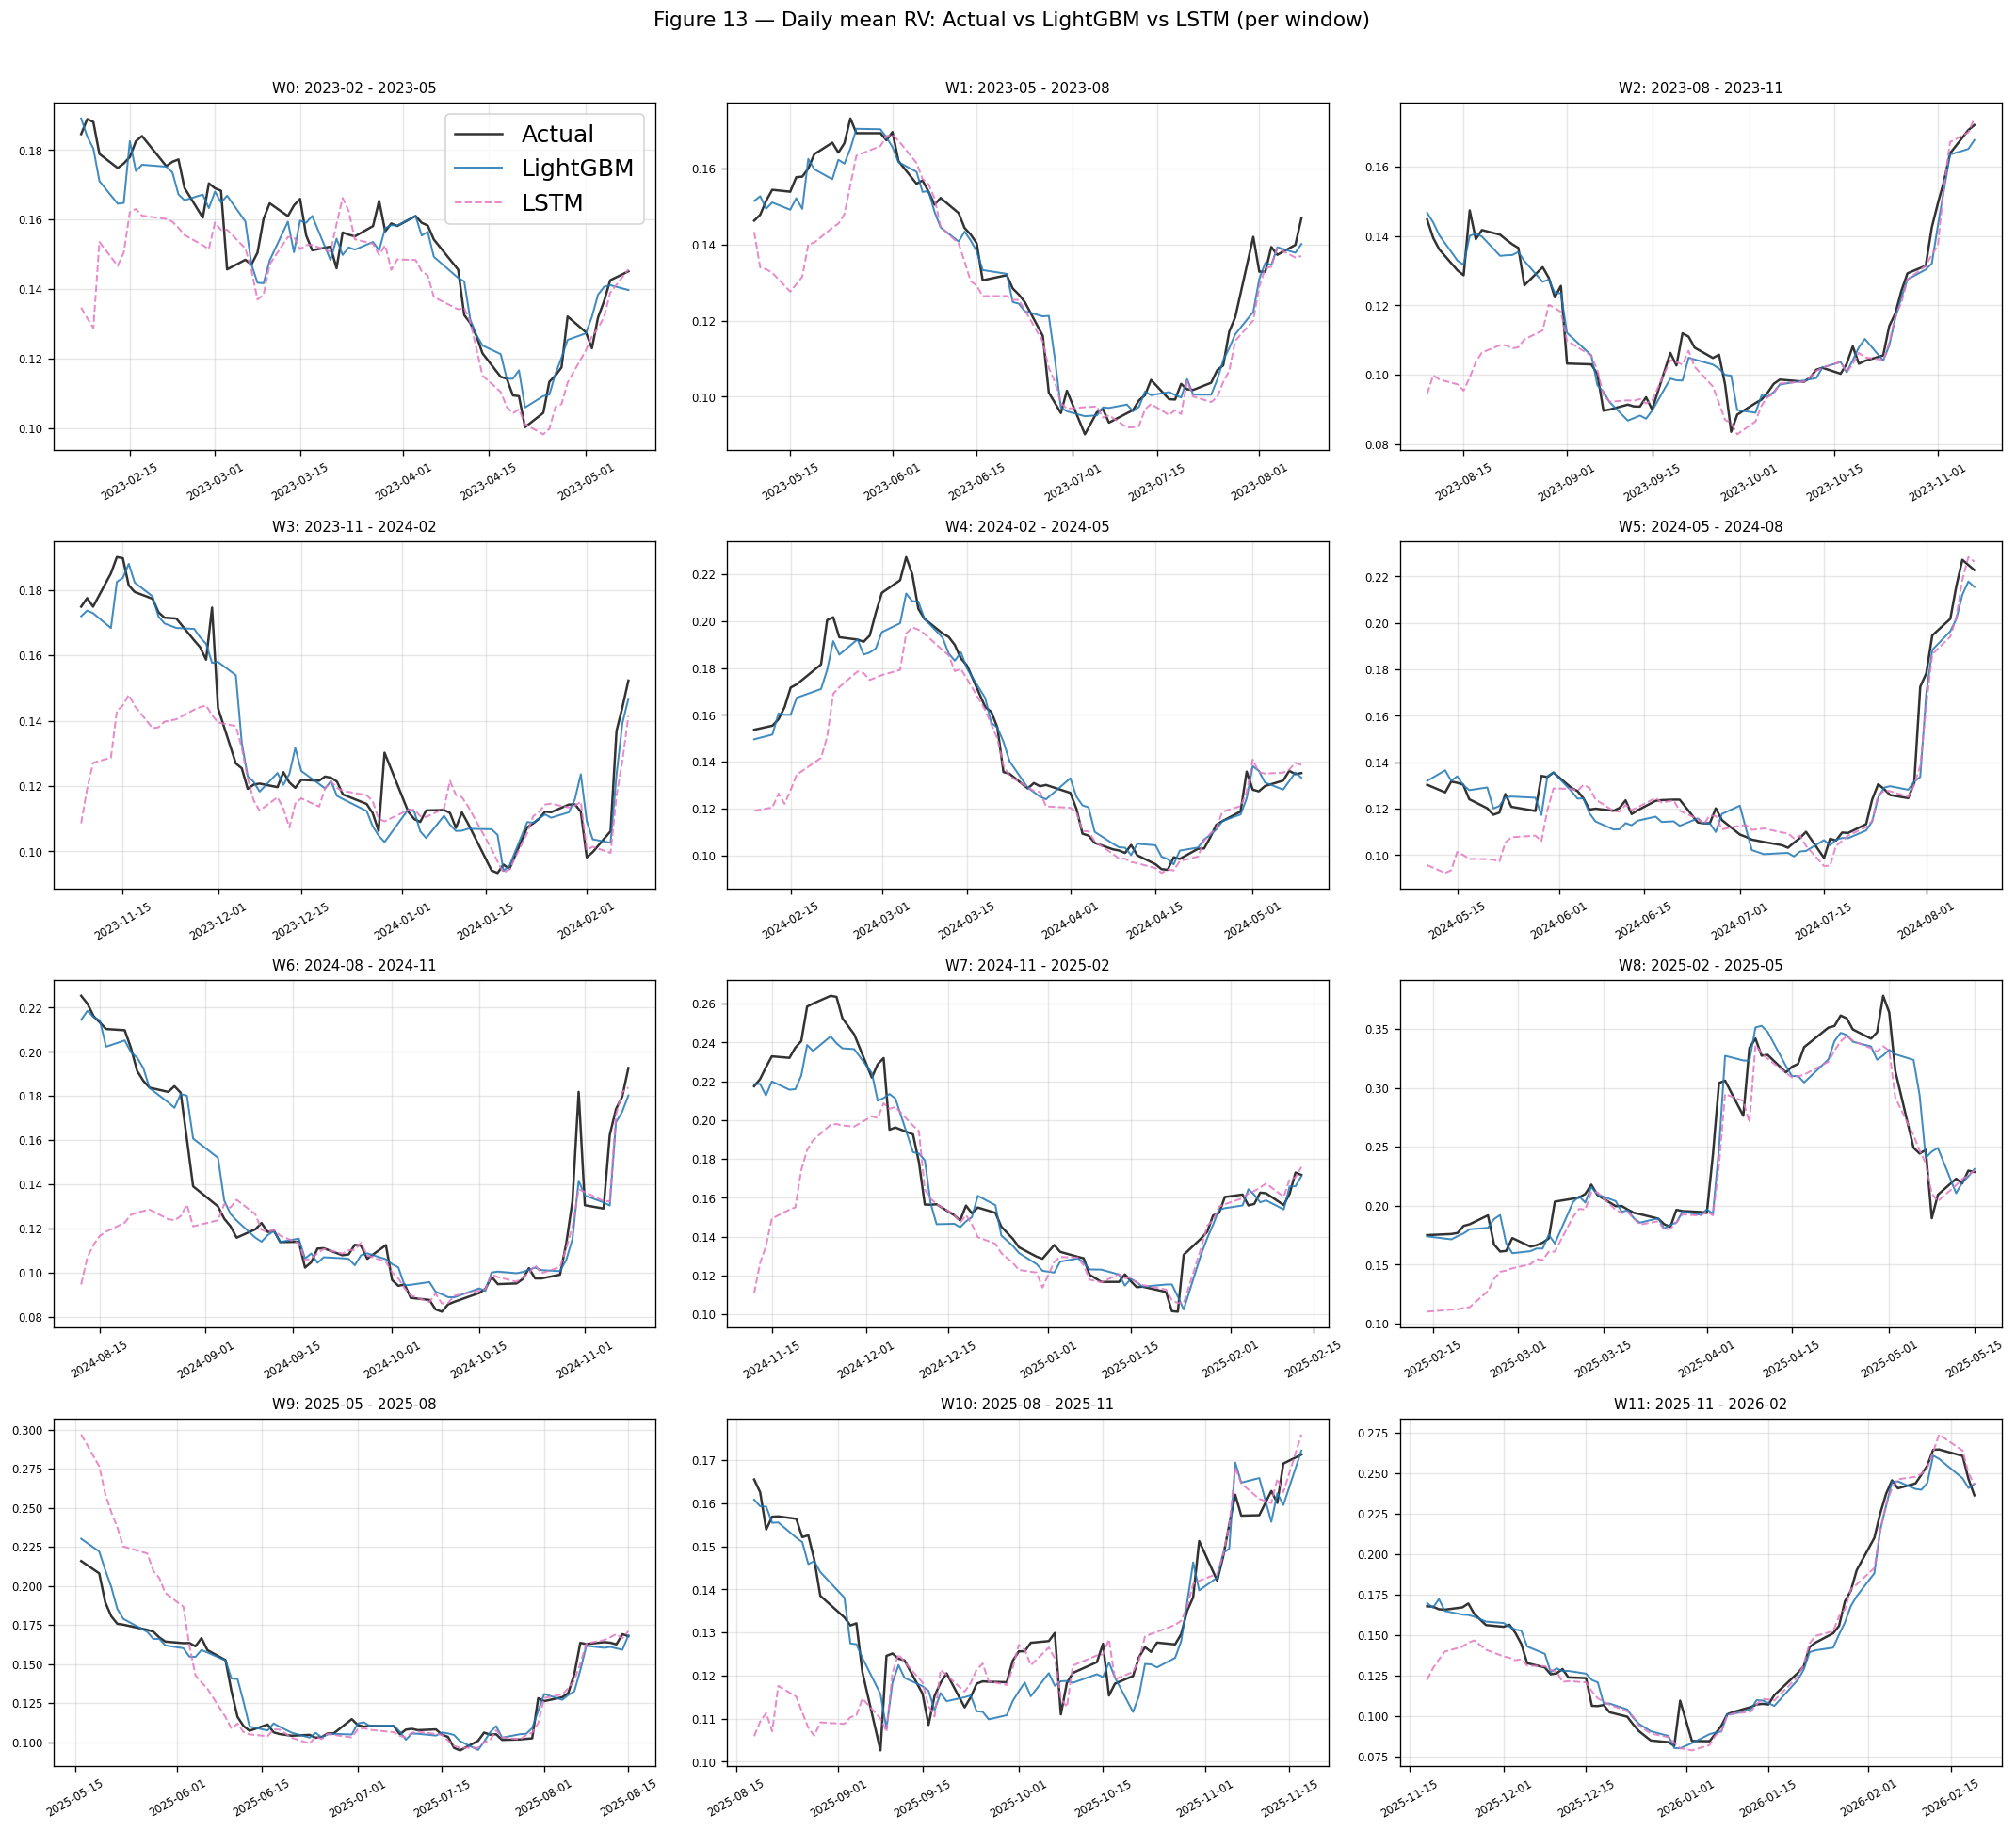

In [9]:
# Daily cross-sectional mean: actual vs LightGBM vs LSTM per window
fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=False)
axes = axes.flatten()

for wid in range(12):
    ax = axes[wid]
    
    # Actual (from LightGBM rows — same y_true for all models on same dates)
    lgbm_w = ap.filter((pl.col("model") == "LightGBM") & (pl.col("window_id") == wid))
    lstm_w = ap.filter((pl.col("model") == "LSTM") & (pl.col("window_id") == wid))
    
    # Daily mean across symbols
    actual_daily = lgbm_w.group_by("date").agg(pl.col("y_true").mean()).sort("date")
    lgbm_daily = lgbm_w.group_by("date").agg(pl.col("y_pred").mean()).sort("date")
    lstm_daily = lstm_w.group_by("date").agg(pl.col("y_pred").mean()).sort("date")
    
    dates_a = actual_daily["date"].to_list()
    ax.plot(dates_a, actual_daily["y_true"].to_list(), color="black", linewidth=1.5,
            label="Actual", alpha=0.8)
    ax.plot(lgbm_daily["date"].to_list(), lgbm_daily["y_pred"].to_list(),
            color=COLORS["LightGBM"], linewidth=1.2, label="LightGBM", alpha=0.85)
    ax.plot(lstm_daily["date"].to_list(), lstm_daily["y_pred"].to_list(),
            color=COLORS["LSTM"], linewidth=1.2, label="LSTM", linestyle="--", alpha=0.85)
    
    # Window label
    test_start = str(dates_a[0])[:10] if dates_a else "?"
    test_end = str(dates_a[-1])[:10] if dates_a else "?"
    ax.set_title(f"W{wid}: {test_start[:7]} - {test_end[:7]}", fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    
    if wid == 0:
        ax.legend(fontsize=15, loc="upper right")

fig.suptitle("Figure 13 — Daily mean RV: Actual vs LightGBM vs LSTM (per window)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Per-Symbol Time Series — Selected Stocks

Concatenated walk-forward predictions across all 12 windows for 6 representative symbols. Vertical dashed lines mark window boundaries.

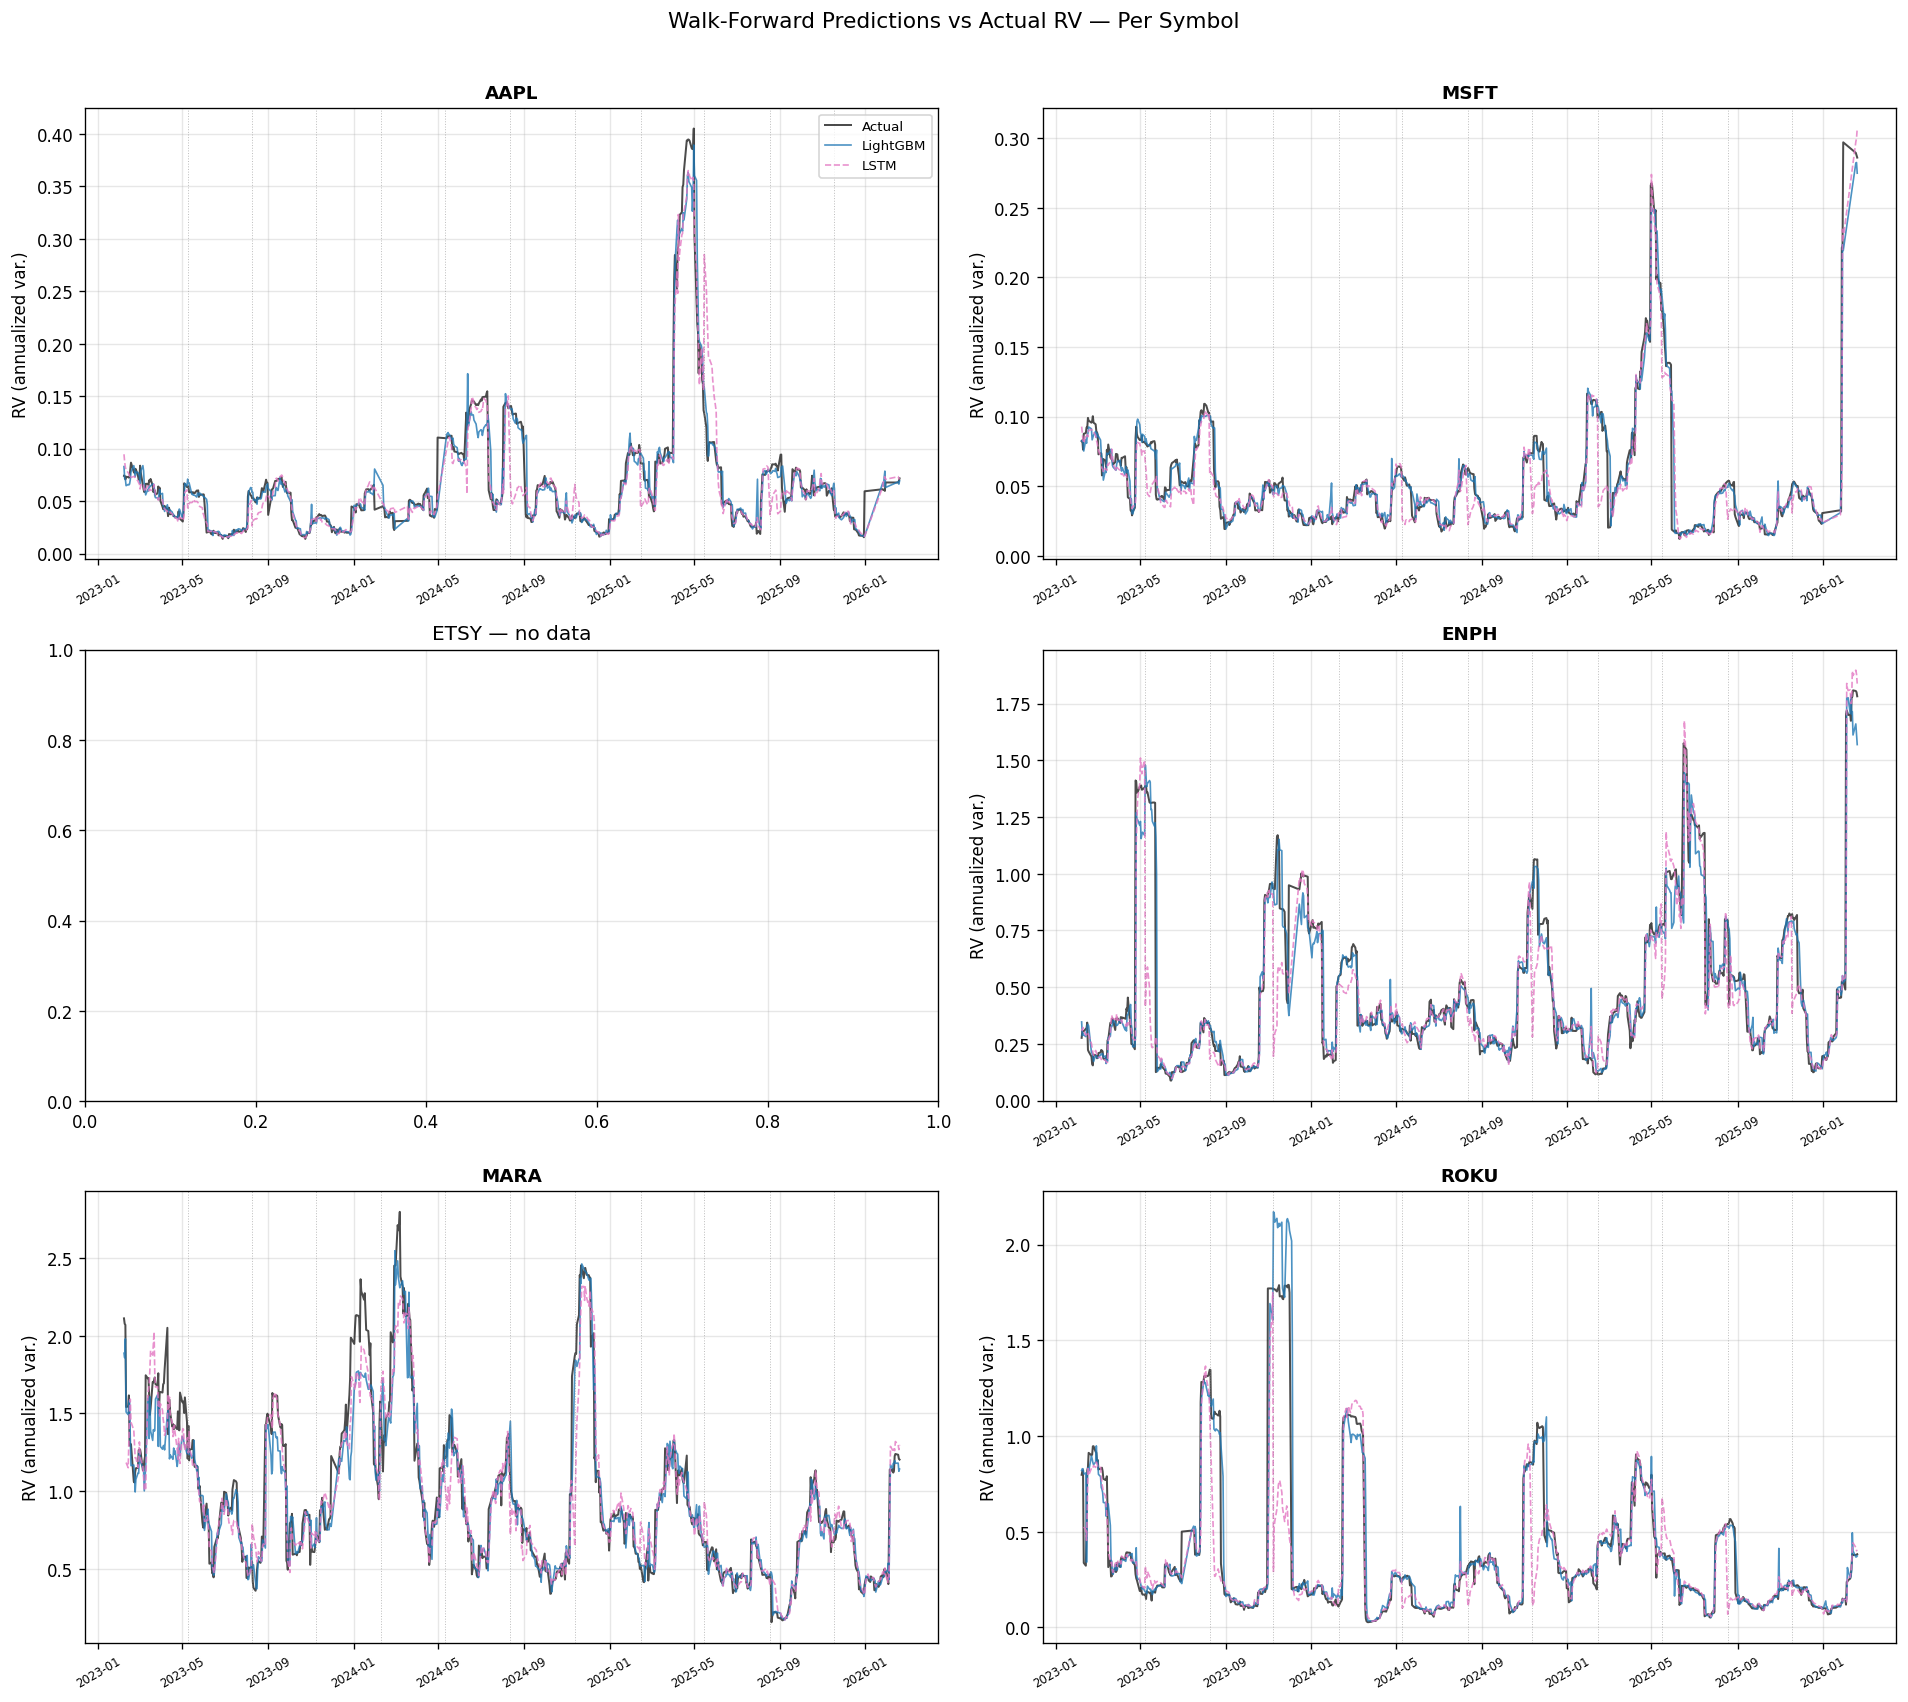

In [10]:
# Per-symbol time series: concatenate all windows for selected symbols
# Pick 6 symbols: 2 large-cap, 2 mid-cap, 2 volatile
SYMBOLS = ["AAPL", "MSFT", "ETSY", "ENPH", "MARA", "ROKU"]

# Get window boundaries for vertical lines
window_starts = (
    wm.filter(pl.col("model") == "HAR")
    .sort("window_id")["test_start"]
    .to_list()
)
import datetime
window_boundaries = [datetime.date.fromisoformat(d) for d in window_starts[1:]]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, symbol in enumerate(SYMBOLS):
    ax = axes[idx]
    
    # Get LightGBM and LSTM predictions for this symbol across all windows
    lgbm_sym = (ap.filter((pl.col("model") == "LightGBM") & (pl.col("symbol") == symbol))
                .sort("date"))
    lstm_sym = (ap.filter((pl.col("model") == "LSTM") & (pl.col("symbol") == symbol))
                .sort("date"))
    
    if len(lgbm_sym) == 0:
        ax.set_title(f"{symbol} — no data")
        continue
    
    # Deduplicate overlapping windows: keep prediction from latest window
    lgbm_dedup = lgbm_sym.sort(["date", "window_id"]).group_by("date").last().sort("date")
    lstm_dedup = lstm_sym.sort(["date", "window_id"]).group_by("date").last().sort("date")
    
    # Plot
    ax.plot(lgbm_dedup["date"].to_list(), lgbm_dedup["y_true"].to_list(),
            color="black", linewidth=1.2, label="Actual", alpha=0.7)
    ax.plot(lgbm_dedup["date"].to_list(), lgbm_dedup["y_pred"].to_list(),
            color=COLORS["LightGBM"], linewidth=1.0, label="LightGBM", alpha=0.8)
    ax.plot(lstm_dedup["date"].to_list(), lstm_dedup["y_pred"].to_list(),
            color=COLORS["LSTM"], linewidth=1.0, label="LSTM", linestyle="--", alpha=0.8)
    
    # Window boundaries
    for wb in window_boundaries:
        ax.axvline(wb, color="gray", linestyle=":", linewidth=0.6, alpha=0.5)
    
    ax.set_title(f"{symbol}", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.set_ylabel("RV (annualized var.)")
    
    if idx == 0:
        ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Walk-Forward Predictions vs Actual RV — Per Symbol", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Predicted vs Actual Scatter — LightGBM vs LSTM

All walk-forward predictions pooled. Perfect prediction falls on the 45-degree line.

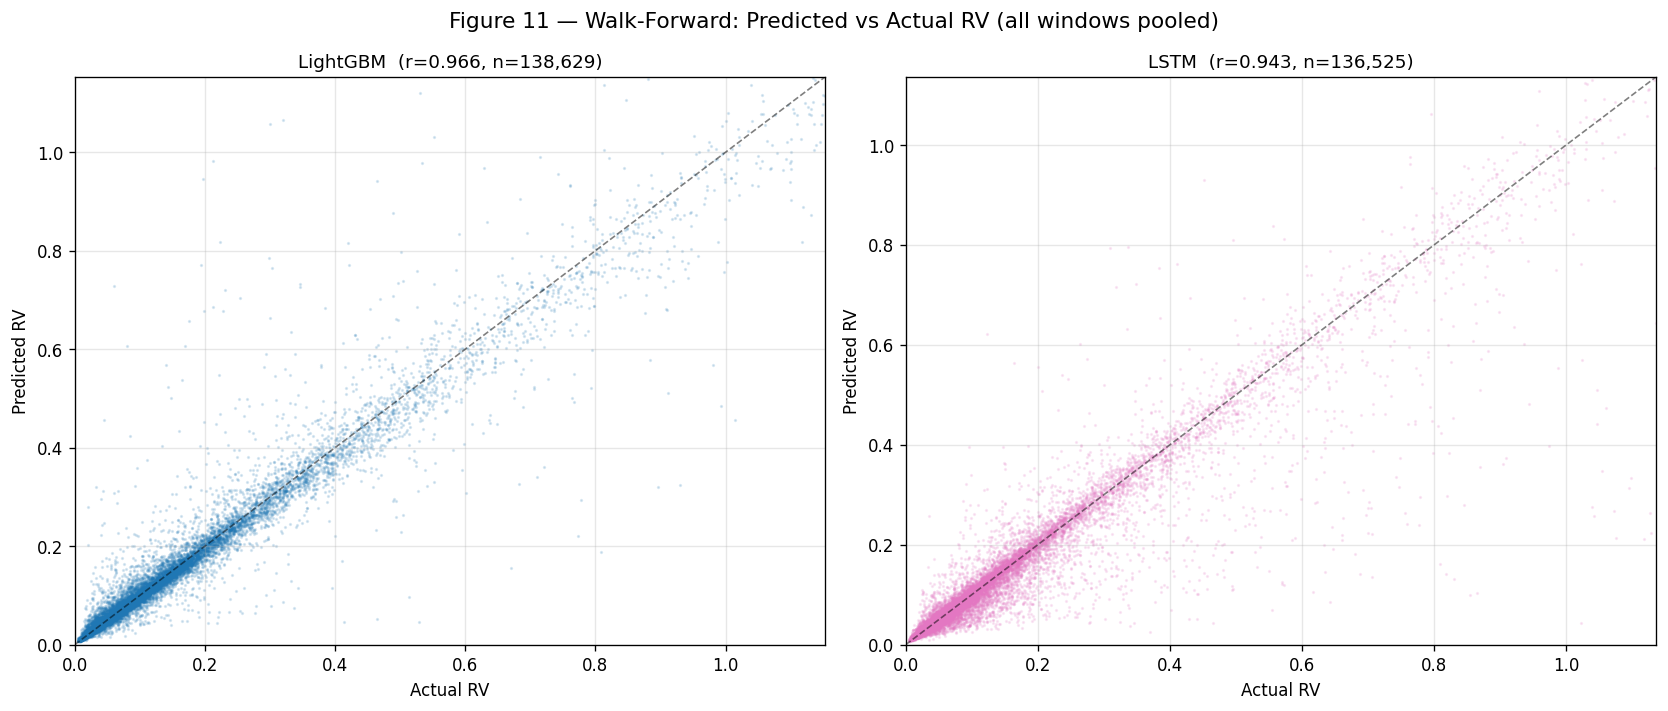

In [11]:
# Scatter: predicted vs actual for LightGBM and LSTM (all windows pooled)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, model_name in [(ax1, "LightGBM"), (ax2, "LSTM")]:
    sub = ap.filter(pl.col("model") == model_name)
    y_true = sub["y_true"].to_numpy()
    y_pred = sub["y_pred"].to_numpy()
    
    # Subsample for plotting (too many points)
    rng = np.random.default_rng(42)
    n_plot = min(20_000, len(y_true))
    idx = rng.choice(len(y_true), n_plot, replace=False)
    
    ax.scatter(y_true[idx], y_pred[idx], s=1, alpha=0.15, color=COLORS[model_name])
    
    # 45-degree line
    lim_max = max(np.percentile(y_true, 99), np.percentile(y_pred, 99))
    ax.plot([0, lim_max], [0, lim_max], "k--", linewidth=1, alpha=0.5)
    
    # Correlation
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    ax.set_title(f"{model_name}  (r={corr:.3f}, n={len(y_true):,})", fontsize=11)
    ax.set_xlabel("Actual RV")
    ax.set_ylabel("Predicted RV")
    ax.set_xlim(0, lim_max)
    ax.set_ylim(0, lim_max)

fig.suptitle("Figure 11 — Walk-Forward: Predicted vs Actual RV (all windows pooled)", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Summary

**Key findings:**

1. **LightGBM is the robust winner** -- best QLIKE in all 12 windows, mean 0.0231 (-17.5% vs LogHAR), statistically significant (DM p<0.001). Low variance (std=0.0028) confirms temporal stability.

2. **LSTM fails walk-forward even when retrained** -- mean QLIKE 0.0428 (retrained) vs 0.0387 (frozen). Both significantly worse than LogHAR. Retraining with fresh weights each window didn't help; the architecture itself struggles with quarterly out-of-sample generalization on this dataset size.

3. **HAR baselines are remarkably stable** -- LogHAR, SHAR, HARQ all cluster around 0.028 with low variance. Volatility persistence (captured by HAR lags) is a strong, robust signal.

4. **Implication for production:** LightGBM with periodic retraining (quarterly expanding window) is the recommended approach.

5. **Dissertation narrative:** Single-split evaluation overstates LSTM's advantage (QLIKE 0.0160 vs 0.0428 in walk-forward). LightGBM's robustness under temporal validation makes it the primary model recommendation. Report both results honestly -- LSTM shows potential with sufficient data but lacks generalization under realistic validation.